# Preparing a Disease Detection Model for Parkinson's
- F0, breathy voice, pauses, intensity
- eGeMAPSv02 feature set from opensmile-python

## Prep

In [ ]:
#for the dataset, unzipping from Files
from google.colab import files
import zipfile
import os

In [ ]:
uploaded = files.upload()
zip_path = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/PD_HC_Samples')
#note for Mel: in PD file on Desktop
!ls /content/PD_HC_Samples

Saving PD + HC Voice Samples.zip to PD + HC Voice Samples (2).zip
'PD + HC Voice Samples'


In [ ]:
#now for the dataframe
import glob
import pandas as pd

#note that my paths are unique; yours will be too
hc_files = glob.glob('/content/PD_HC_Samples/PD + HC Voice Samples/HC/*.wav')
pd_files = glob.glob('/content/PD_HC_Samples/PD + HC Voice Samples/PD/*.wav')

#binary baddies for the regression lifestyle in one dataframe
hc_df = pd.DataFrame({'filepath': hc_files, 'label': 0})
pd_df = pd.DataFrame({'filepath': pd_files, 'label': 1})
all_files_df = pd.concat([hc_df, pd_df], ignore_index=True)

In [ ]:
#take the opensmile route for feature extraction
!pip install opensmile

In [ ]:
#relevant pkgs
import opensmile
import pandas as pd
from tqdm import tqdm
import os

In [ ]:
#initializing
smile = opensmile.Smile(
    feature_set=opensmile.FeatureSet.eGeMAPSv02,
    feature_level=opensmile.FeatureLevel.Functionals,
)

In [ ]:
#now for all
def extract_features(df):
    all_features = []
    for i, row in tqdm(df.iterrows(), total=len(df)):
        path = row['filepath']
        feats = smile.process_file(path)
        feats['label'] = row['label']  # add label column
        all_features.append(feats)
    return pd.concat(all_features, ignore_index=True)

#ah, makes more sense to get a train/test from the eGeMAPSv02 ig
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(all_files_df, test_size=0.2, random_state=42, stratify=all_files_df['label'])

#extraction
train_features = extract_features(train_df)
test_features = extract_features(test_df)

print("Training feature set shape:", train_features.shape)
print("Testing feature set shape:", test_features.shape)

100%|██████████| 17/17 [00:02<00:00,  6.46it/s]

Training feature set shape: (64, 89)
Testing feature set shape: (17, 89)


In [ ]:
audio_path = all_files_df['filepath'].iloc[0]
features = smile.process_file(audio_path)

In [ ]:
#extract features from one file
audio_path = all_files_df['filepath'].iloc[0]
features = smile.process_file(audio_path)

# Feature Extraction

Currently operating under the assumption that the following are FOI:


*   F0 mean and SD
*   Loudness mean and SD
*   shimmer mean and SD
*   HNR mean and SD



In [ ]:
#filter
f0_cols = [
    'F0semitoneFrom27.5Hz_sma3nz_amean',
    'F0semitoneFrom27.5Hz_sma3nz_stddevNorm'
]
intensity_cols = [
    'loudness_sma3_amean',
    'loudness_sma3_stddevNorm'
]
vq_cols = [
    'shimmerLocaldB_sma3nz_amean',
    'shimmerLocaldB_sma3nz_stddevNorm',
    'HNRdBACF_sma3nz_amean',
    'HNRdBACF_sma3nz_stddevNorm'
]
#combine
selected_cols = f0_cols + intensity_cols + vq_cols
#create new df
selected_features = features[selected_cols]

#FOIs only here
train_selected = train_features[selected_cols + ['label']]
test_selected = test_features[selected_cols + ['label']]

In [ ]:
#creating metadata layer for some visualizations or easy access
feature_categories = {}

for f in f0_cols: feature_categories[f] = 'F0'
for f in intensity_cols: feature_categories[f] = 'Intensity'
for f in vq_cols: feature_categories[f] = 'VoiceQuality'
feature_categories['label'] = 'Label'

#check the onboarding
#print(feature_categories)

### Visualization (for correlations and collinearity)

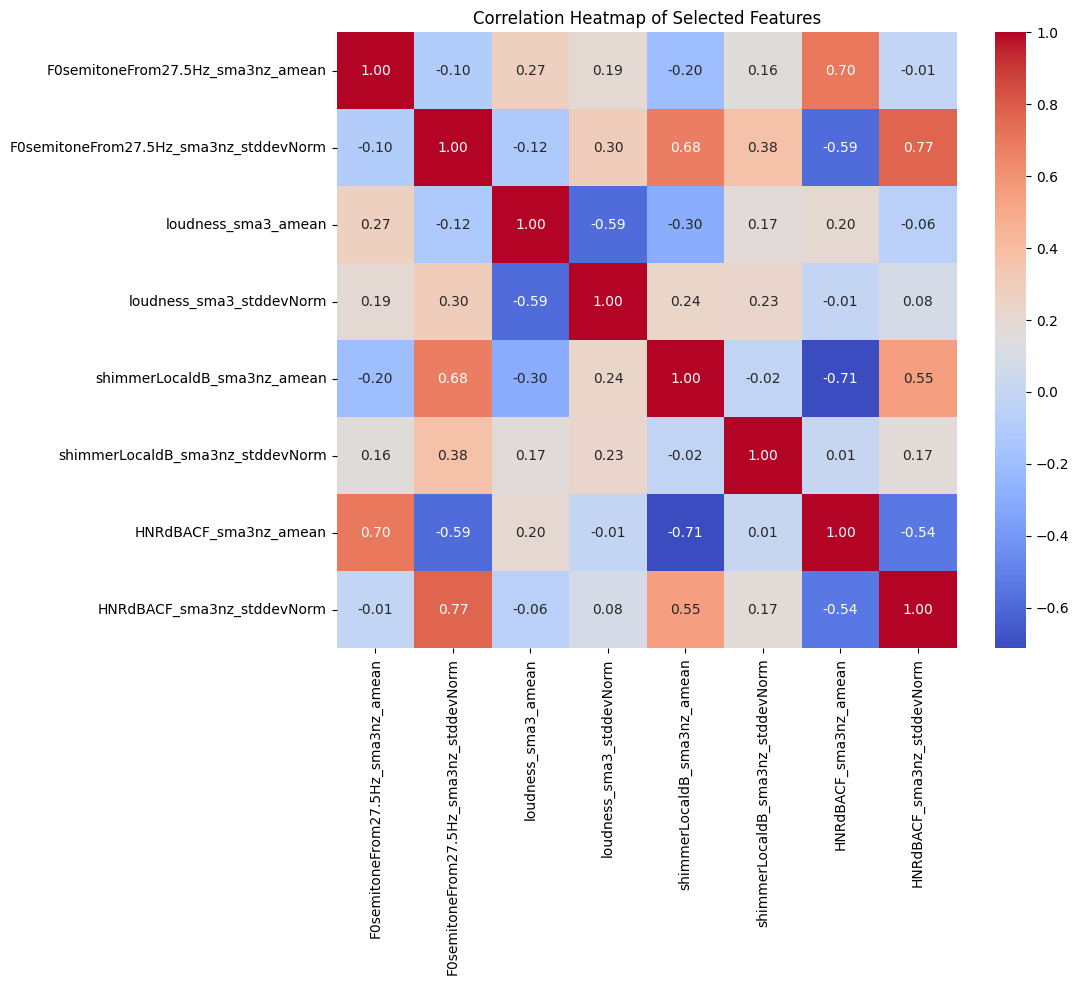

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#heatmap realness for correlations
corr = train_selected.drop(columns='label').corr()
plt.figure(figsize=(10, 8)) #size matters <3
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f") #love the values
plt.title('Correlation Heatmap of Selected Features')
plt.show()

#findings: pitch and loudness highly correlated...ratio time?
#values not catastrophic but a ratio
#captures the balance between pitch and harmonic purity

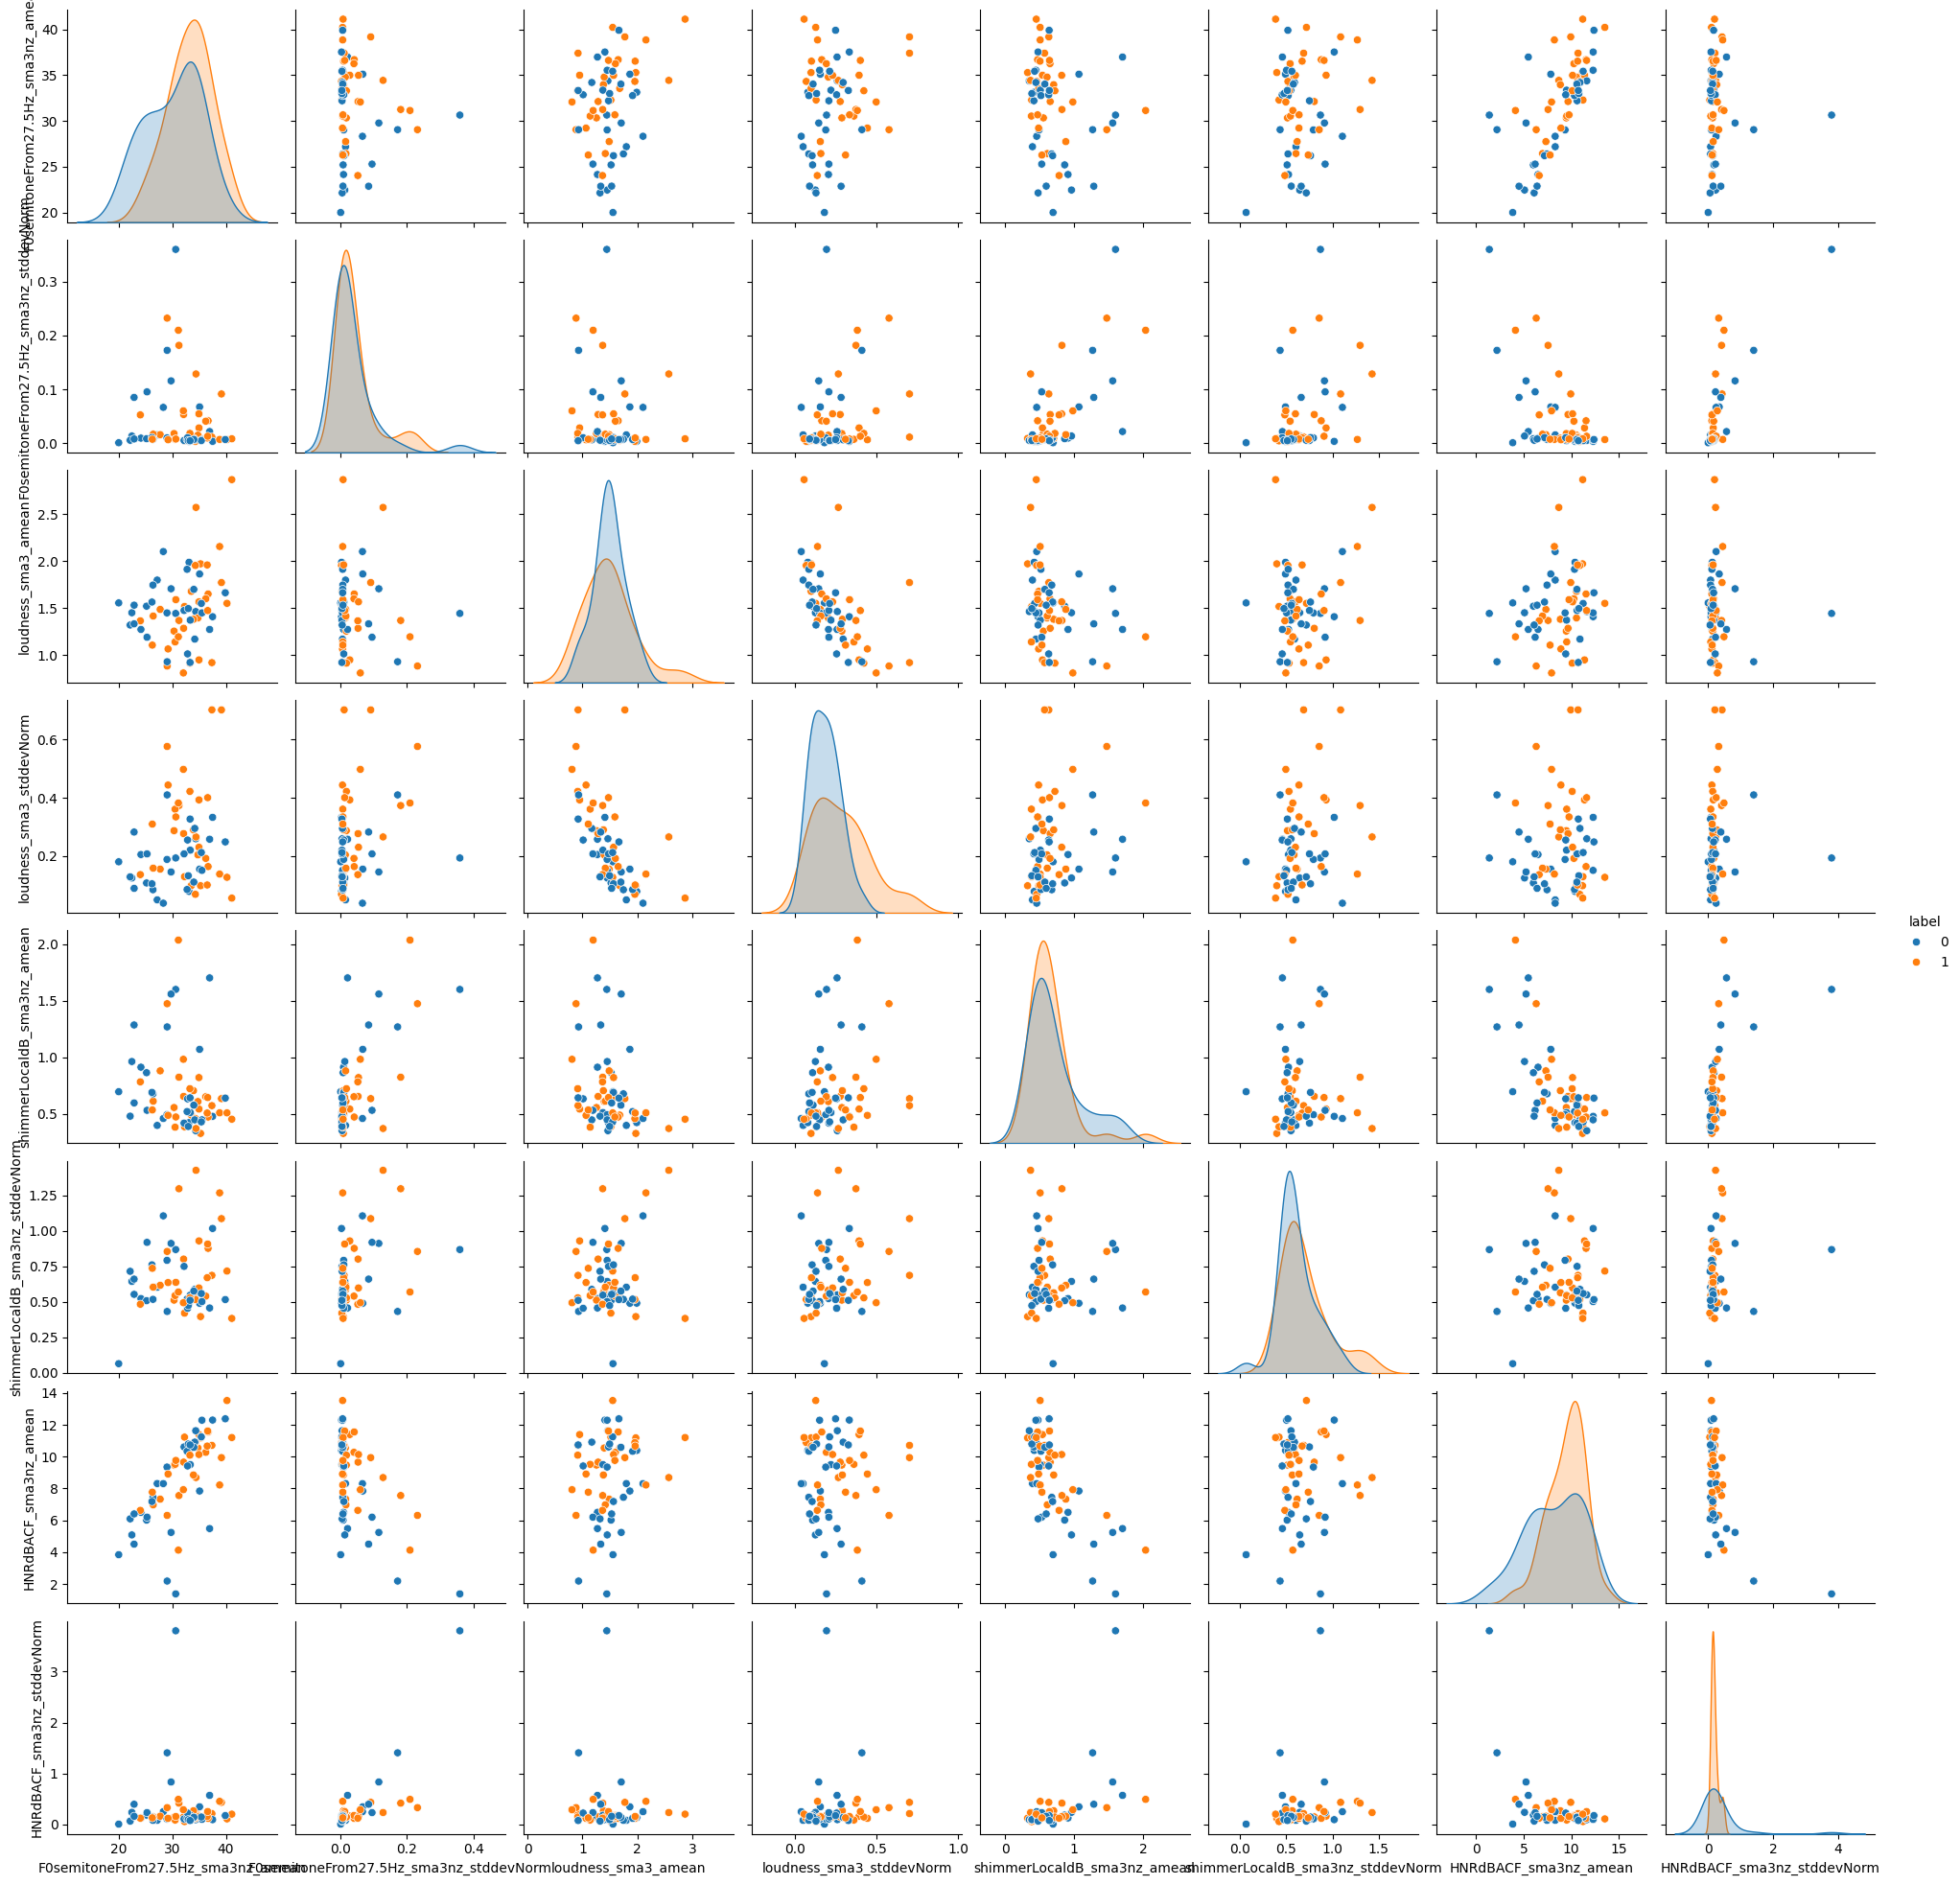

In [ ]:
#for checking the feature separability
sns.pairplot(train_selected, hue='label', vars=selected_cols)
plt.show()
#...shit

# FOI Models
1.   Logistic Regression
2.   SVM

In [ ]:
#reitierating some things here
from sklearn.model_selection import train_test_split #for manually resplitting data later

# X = features (FOI input), y = label (detection: HC/PD)
X_train = train_selected.drop(columns=['label']) #no labels here, features only; input matrix created!
y_train = train_selected['label'] #1D vector of 0s and 1s

#for checking generalization
X_test = test_selected.drop(columns=['label'])
y_test = test_selected['label']

#training samples × feature values per sample
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (64, 8)
Test shape: (17, 8)


In [ ]:
#scaling always
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Regressions

In [ ]:
#regression time
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

#initializing and fitting
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train) #training the model actually

#predictions
y_pred_lr = lr_model.predict(X_test_scaled)

#checking for accuracy
print("Logistic Regression Results:")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results:
[[5 4]
 [2 6]]
              precision    recall  f1-score   support

           0       0.71      0.56      0.62         9
           1       0.60      0.75      0.67         8

    accuracy                           0.65        17
   macro avg       0.66      0.65      0.65        17
weighted avg       0.66      0.65      0.64        17



### SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

#initializing
svm_model = SVC(
    kernel='linear',    # linear kernel for interpretability
    C=1.0,              # regularization strength
    class_weight='balanced',  # optional, if dataset is imbalanced
    random_state=42
)

#training
svm_model.fit(X_train_scaled, y_train)

#test set prediction
y_pred = svm_model.predict(X_test_scaled)

#evaluation
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.56      0.62         9
           1       0.60      0.75      0.67         8

    accuracy                           0.65        17
   macro avg       0.66      0.65      0.65        17
weighted avg       0.66      0.65      0.64        17

[[5 4]
 [2 6]]


# Inclusive Models
Ensuring that the FOI are meaningful and robust.

1.   Logisitic Regression
2.   SVM



In [ ]:
#zooming out
all_feature_cols = [col for col in train_features.columns if col != 'label']

#train/test sets
X_train = train_features[all_feature_cols]
y_train = train_features['label']

X_test = test_features[all_feature_cols]
y_test = test_features['label']

In [ ]:
#scaling always
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#training
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l2')
lr_model.fit(X_train_scaled, y_train)

#predictions
y_pred_lr = lr_model.predict(X_test_scaled)

#checking for accuracy
print("Logistic Regression Results:")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results:
[[6 3]
 [2 6]]
              precision    recall  f1-score   support

           0       0.75      0.67      0.71         9
           1       0.67      0.75      0.71         8

    accuracy                           0.71        17
   macro avg       0.71      0.71      0.71        17
weighted avg       0.71      0.71      0.71        17



In [ ]:
#training
from sklearn.svm import SVC

svm_model = SVC(kernel='linear', C=1.0, class_weight='balanced')
svm_model.fit(X_train_scaled, y_train)

#test set prediction
y_pred = svm_model.predict(X_test_scaled)

#evaluation
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.44      0.53         9
           1       0.55      0.75      0.63         8

    accuracy                           0.59        17
   macro avg       0.61      0.60      0.58        17
weighted avg       0.61      0.59      0.58        17

[[4 5]
 [2 6]]


### Relevance?

In [ ]:
#what is actually important?
#according to LR
import pandas as pd

feature_importance = pd.Series(lr_model.coef_[0], index=all_feature_cols)
feature_importance.sort_values(key=abs, ascending=False).head(10)  #top 10
print(feature_importance)

F0semitoneFrom27.5Hz_sma3nz_amean             0.062265
F0semitoneFrom27.5Hz_sma3nz_stddevNorm        0.393762
F0semitoneFrom27.5Hz_sma3nz_percentile20.0    0.036144
F0semitoneFrom27.5Hz_sma3nz_percentile50.0   -0.011867
F0semitoneFrom27.5Hz_sma3nz_percentile80.0    0.072096
                                                ...   
MeanVoicedSegmentLengthSec                    0.195261
StddevVoicedSegmentLengthSec                  0.251749
MeanUnvoicedSegmentLength                     0.195788
StddevUnvoicedSegmentLength                  -0.110152
equivalentSoundLevel_dBp                      0.384898
Length: 88, dtype: float64


In [ ]:
#according to SVM
svm_importance = pd.Series(svm_model.coef_[0], index=all_feature_cols)
svm_importance.sort_values(key=abs, ascending=False).head(10)
print(svm_importance)

F0semitoneFrom27.5Hz_sma3nz_amean            -0.048363
F0semitoneFrom27.5Hz_sma3nz_stddevNorm        0.392037
F0semitoneFrom27.5Hz_sma3nz_percentile20.0   -0.084090
F0semitoneFrom27.5Hz_sma3nz_percentile50.0   -0.079217
F0semitoneFrom27.5Hz_sma3nz_percentile80.0   -0.009836
                                                ...   
MeanVoicedSegmentLengthSec                    0.128171
StddevVoicedSegmentLengthSec                  0.059163
MeanUnvoicedSegmentLength                     0.043267
StddevUnvoicedSegmentLength                  -0.042005
equivalentSoundLevel_dBp                      0.188442
Length: 88, dtype: float64


The general models should inform what features of interest are extracted...supposedly.

# Interpretation

LR and SVM accuracy scores from FOI Models are the same. This indicates that FOIs are strong, meaningful predictors. The linear relationships between identifying healthy and PD speakers dominate.

However, the LR confusion matrix improving with all eGeMAPS features included indicates that L2 regularization helps, because it prevents overfitting and leverages weak signals. The SVM likely suffers from dimensionality in this case. Including all 88 features overwhelms the model, creates noise, and introduces multicollinearity.

In short, carefully chosen FOIs (e.g., average means and normalized values of F0, voice quality, and intensity) are more reliable than including all eGeMAPS features in the model—especially in smaller datasets such as this one.